##**Examen transversal de programación de ciencia de datos**

## Integrantes:

*   Maria Alejandra Marambio
*   Pamela Toro

### Fecha: Domingo 5 de julio, 2026.-


#**Contexto:**

En el ámbito del retail masivo y la optimización de cadenas de suministro, el monitoreo del rendimiento en los puntos de venta es una tarea crítica para las corporaciones globales en la toma de decisiones estratégicas. Debido al volumen masivo y fragmentado de datos recopilados diariamente por sistemas transaccionales y fluctuaciones macroeconómicas, se vuelve fundamental el uso de técnicas avanzadas de Ciencia de Datos y procesos ETL automatizados para optimizar la identificación de tiendas de alto rendimiento sin depender de la revisión manual humana. La integración de APIs vivas para la conversión monetaria y el despliegue en entornos reproducibles permiten transformar estos datos crudos en inteligencia de negocios ágil, escalable y libre de errores operacionales.

#**1. Importar las librerías a utilizar**

En esta primera etapa se importan las librerías necesarias:

pandas: permite cargar datos tabulares, limpiar y transformar los datos.

numpy: permite trabajar con valores numéricos y valores nulos.

matplotlib.pyplot: permite crear gráficos y visualizaciones básicas.

seaborn: permite crear gráficos estadísticos de alta calidad con estilos visuales integrados y predefinidos.

warnings: permite gestionar las advertencias generadas por el código; en este caso, se configura para ignorarlas ('ignore') y mantener la consola limpia de alertas por versiones o funciones obsoletas.

plotly.express: permite crear gráficos interactivos y dinámicos de manera rápida y con pocas líneas de código.

plotly.graph_objects: permite crear y personalizar gráficos interactivos con un control mucho más detallado y avanzado sobre cada componente visual.

iplot (de plotly.offline): permite renderizar e interactuar con los gráficos de Plotly de forma local y directa dentro de entornos como Jupyter Notebooks sin necesidad de estar conectado a internet.

requests: permite realizar peticiones HTTP para interactuar con servidores web, lo que facilita el consumo y la descarga de datos desde APIs REST.

os: permite interactuar con el sistema operativo para gestionar rutas, carpetas y verificar la existencia de archivos locales.

datetime (de datetime): permite manipular, formatear y realizar operaciones con fechas y horas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot
import requests
import os
from datetime import datetime



#**1.1 ETL**

En esta fase del proyecto se desarrolla el pipeline ETL para centralizar, estandarizar y asegurar la calidad de las fuentes de información antes de su almacenamiento o análisis. El flujo se compone de las siguientes etapas reflejadas en el código:

- Extracción (Extract): Se realiza la ingesta simultánea de dos fuentes: el archivo local dataset_car_seats.csv mediante pandas y el tipo de cambio actualizado en formato JSON desde la API de DolarApi usando requests.

- Transformación (Transform): Se crea una copia del dataset para aplicar las reglas de negocio y se añade un control de excepciones crítico: si la API responde con un valor de cero (0), el código activa una contingencia que inyecta un valor por defecto de $913.99 CLP, evitando fallos en los cálculos monetarios posteriores.

- Carga (Load): Se valida el éxito del proceso mediante un reporte en consola que confirma la consistencia de los datos (400 registros cargados) y el valor final del dólar que utilizará el sistema.

In [ ]:
df_original = pd.read_csv('dataset_car_seats.csv')
df_copia = df_original.copy()
df_copia.head(3)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes


In [ ]:
df_original.head(10)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


In [ ]:
# variables numericas
df_original[['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education']].head()

,CompPrice,Income,Advertising,Population,Price,Age,Education
0,138,73,11,276,120,42,17
1,111,48,16,260,83,65,10
2,113,35,10,269,80,59,12
3,117,100,4,466,97,55,14
4,141,64,3,340,128,38,13


In [ ]:
url = 'https://cl.dolarapi.com/v1/cotizaciones/usd'
r = requests.get(url)
datos_api = r.json()

In [ ]:
pd.DataFrame([datos_api])

,moneda,nombre,compra,venta,ultimoCierre,fechaActualizacion
0,USD,Dólar,919.75,922.45,919.75,2026-07-04T12:02:13.208Z


In [ ]:
valor_dolar = datos_api['venta']

# --- MODIFICACIÓN AGREGADA --- #
# Si la API devuelve 0 para el valor de venta, usar un valor por defecto.
# Esto corrige el problema de que todas las columnas CLP sean 0.
if valor_dolar == 0:
    print("Advertencia: La API del dólar devolvió 0. Usando valor por defecto de 913.99 CLP para el dólar.")
    valor_dolar = 913.99  # Valor por defecto para asegurar que las conversiones funcionen
# --- FIN MODIFICACIÓN --- #

In [ ]:
print(f"-> Dataset extraído correctamente. Registros: {df_copia.shape[0]}")
print(f"-> API consultada exitosamente. Valor del dólar obtenido: ${valor_dolar:.2f} CLP")

-> Dataset extraído correctamente. Registros: 400
-> API consultada exitosamente. Valor del dólar obtenido: $922.45 CLP


In [ ]:
# Verifica si cada fila es un duplicado
df_original.duplicated().sum()

np.int64(0)

In [ ]:
df_original.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,400.0,199.500000,115.614301,0.0,99.75,199.50,299.25,399.00
Sales,400.0,7.496325,2.824115,0.0,5.39,7.49,9.32,16.27
CompPrice,400.0,124.975000,15.334512,77.0,115.00,125.00,135.00,175.00
Income,400.0,68.657500,27.986037,21.0,42.75,69.00,91.00,120.00
Advertising,400.0,6.635000,6.650364,0.0,0.00,5.00,12.00,29.00
Population,400.0,264.840000,147.376436,10.0,139.00,272.00,398.50,509.00
Price,400.0,115.795000,23.676664,24.0,100.00,117.00,131.00,191.00
Age,400.0,53.322500,16.200297,25.0,39.75,54.50,66.00,80.00
Education,400.0,13.900000,2.620528,10.0,12.00,14.00,16.00,18.00


In [ ]:
# Seleccionar y mostrar las primeras 5 filas de variables específicas
df_original[['ShelveLoc','Urban','US']].head()

,ShelveLoc,Urban,US
0,Bad,Yes,Yes
1,Good,Yes,Yes
2,Medium,Yes,Yes
3,Medium,Yes,Yes
4,Bad,Yes,No


#**1.2 TRANSFORMACIONES DATOS SOLICITADOS**

##**Crear variable booleana llamada HighSales**

In [ ]:
# Crear HighSales
df_copia['HighSales'] = (df_copia['Sales'] > 8).astype(int)
display(df_copia.head(3))

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1


##**Transformar variables de dolar a peso chileno USD -> CLP**

In [ ]:
df_copia['CompPrice_CLP'] = (df_copia['CompPrice']*valor_dolar).round(0).astype(int)
df_copia['Price_CLP'] = (df_copia['Price']*valor_dolar).round(0).astype(int)
df_copia['Income_CLP'] = (df_copia['Income']*valor_dolar).round(0).astype(int)
df_copia['Advertising_CLP'] = (df_copia['Advertising']*valor_dolar).round(0).astype(int)
df_copia.head(3)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales,CompPrice_CLP,Price_CLP,Income_CLP,Advertising_CLP
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,127298,110694,67339,10147
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,102392,76563,44278,14759
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,104237,73796,32286,9224


##**Crear nueva variable de ventas por precio**

In [ ]:
df_copia['Ingreso_miles_CLP'] = (df_copia['Sales']*df_copia['Price_CLP']).round(0).astype(int)
df_copia.head(3)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales,CompPrice_CLP,Price_CLP,Income_CLP,Advertising_CLP,Ingreso_miles_CLP
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,127298,110694,67339,10147,1051593
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,102392,76563,44278,14759,859037
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,104237,73796,32286,9224,742388


##**Eliminar variables antiguas de dolares del dataframe**

In [ ]:
columnas_a_eliminar = ['Unnamed: 0','CompPrice', 'Price', 'Income', 'Advertising']
df_copia = df_copia.drop(columnas_a_eliminar, axis=1, errors='ignore')
df_copia.head(3)

,Sales,Population,ShelveLoc,Age,Education,Urban,US,HighSales,CompPrice_CLP,Price_CLP,Income_CLP,Advertising_CLP,Ingreso_miles_CLP
0,9.50,276,Bad,42,17,Yes,Yes,1,127298,110694,67339,10147,1051593
1,11.22,260,Good,65,10,Yes,Yes,1,102392,76563,44278,14759,859037
2,10.06,269,Medium,59,12,Yes,Yes,1,104237,73796,32286,9224,742388


#**1.3 Preparación y análisis exploratorio de datos.**

In [ ]:
# Revisamos la cantidad de filas y columans del dataset.
print("Cantidad de filas y columnas:")
print(df_copia.shape)

# Revisamos los tipos de datos y valores no nulos de cada columna.
print("\nInformación general del DataFrame:")
df_copia.info()

Cantidad de filas y columnas:
(400, 13)

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales              400 non-null    float64
 1   Population         400 non-null    int64  
 2   ShelveLoc          400 non-null    object 
 3   Age                400 non-null    int64  
 4   Education          400 non-null    int64  
 5   Urban              400 non-null    object 
 6   US                 400 non-null    object 
 7   HighSales          400 non-null    int64  
 8   CompPrice_CLP      400 non-null    int64  
 9   Price_CLP          400 non-null    int64  
 10  Income_CLP         400 non-null    int64  
 11  Advertising_CLP    400 non-null    int64  
 12  Ingreso_miles_CLP  400 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 40.8+ KB


In [ ]:
df_copia.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,400.0,7.496325,2.824115,0.0,5.39,7.49,9.32,16.27
Population,400.0,264.840000,147.376436,10.0,139.00,272.00,398.50,509.00
Age,400.0,53.322500,16.200297,25.0,39.75,54.50,66.00,80.00
Education,400.0,13.900000,2.620528,10.0,12.00,14.00,16.00,18.00
HighSales,400.0,0.410000,0.492449,0.0,0.00,0.00,1.00,1.00
CompPrice_CLP,400.0,115283.182500,14145.315179,71029.0,106082.00,115306.00,124531.00,161429.00
Price_CLP,400.0,106815.107500,21840.553422,22139.0,92245.00,107927.00,120841.00,176188.00
Income_CLP,400.0,63333.122500,25815.725421,19371.0,39434.50,63649.00,83943.00,110694.00
Advertising_CLP,400.0,6120.407500,6134.633638,0.0,0.00,4612.00,11069.00,26751.00
Ingreso_miles_CLP,400.0,773344.670000,279122.267814,0.0,577990.75,760377.50,941942.50,1655111.00


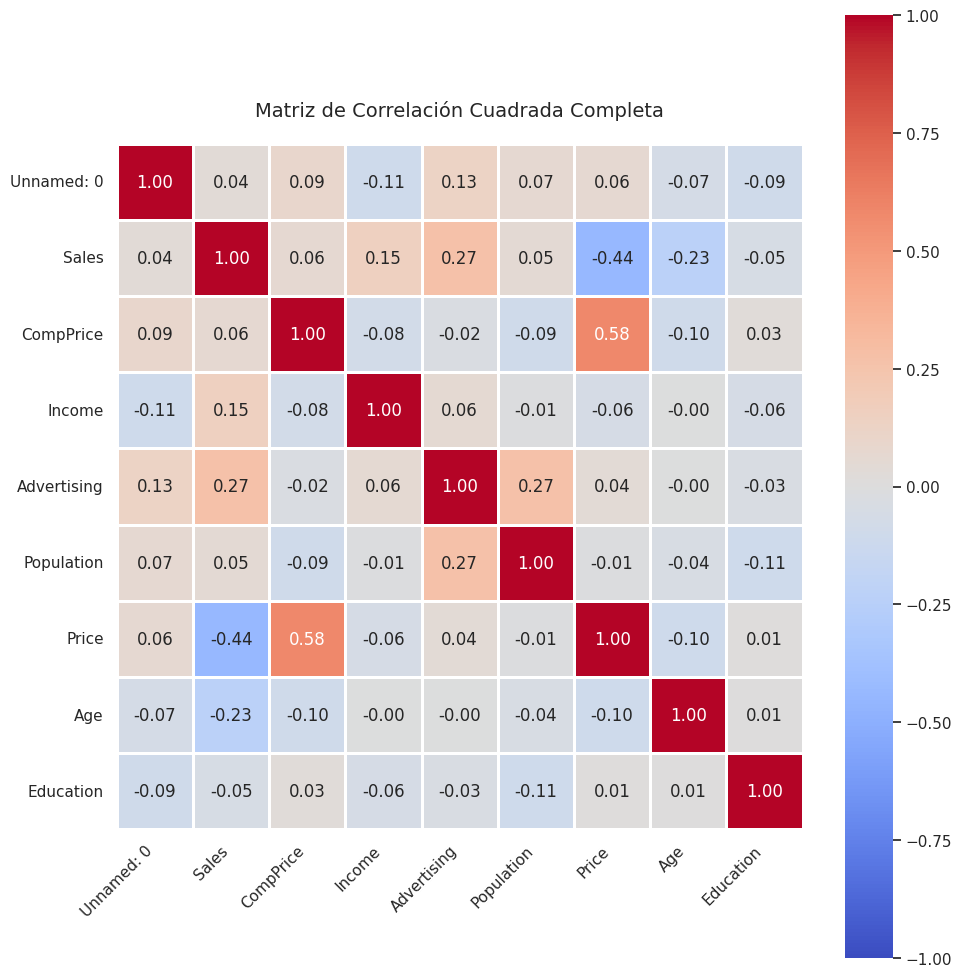

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# 2. Filtrar solo columnas numéricas y calcular la correlación
df_numerico = df_original.select_dtypes(include=[np.number])
matriz_corr = df_numerico.corr()

# 3. Configurar el tamaño del gráfico cuadrado
# Al usar el mismo ancho y alto (ej. 10x10), aseguras la proporción cuadrada
plt.figure(figsize=(10, 10))

# 4. Graficar la matriz CUADRADA completa
sns.heatmap(matriz_corr,
            annot=True,         # Muestra los valores numéricos
            cmap='coolwarm',    # Escala bicolores (Azul = Negativo, Rojo = Positivo)
            fmt=".2f",          # Redondeo a 2 decimales
            vmin=-1, vmax=1,    # Límites estándar de la correlación de Pearson
            linewidths=0.8,     # Líneas de separación entre celdas
            square=True)        # <--- FUERZA a que cada celda sea un cuadrado perfecto

# 5. Ajustes de etiquetas y visualización
plt.title('Matriz de Correlación Cuadrada Completa', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Calculamos la cantidad de valores faltentes por columna.
valores_faltantes = df_copia.isnull().sum()

# Calculamos la cantidad de filas duplicadas.
duplicados = df_copia.duplicated().sum()

print("Valores faltantes por columna:")
display(valores_faltantes)

print("\nCantidad de filas duplicadas:")
print(duplicados)

Valores faltantes por columna:


,0
Sales,0
Population,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0
HighSales,0
CompPrice_CLP,0
Price_CLP,0



Cantidad de filas duplicadas:
0


##**Outliers:**

Al observar los boxplots, nos podemos dar cuenta de que no tenemos tantos valores atípicos, por lo que éstos no serán tratados de ninguna manera.

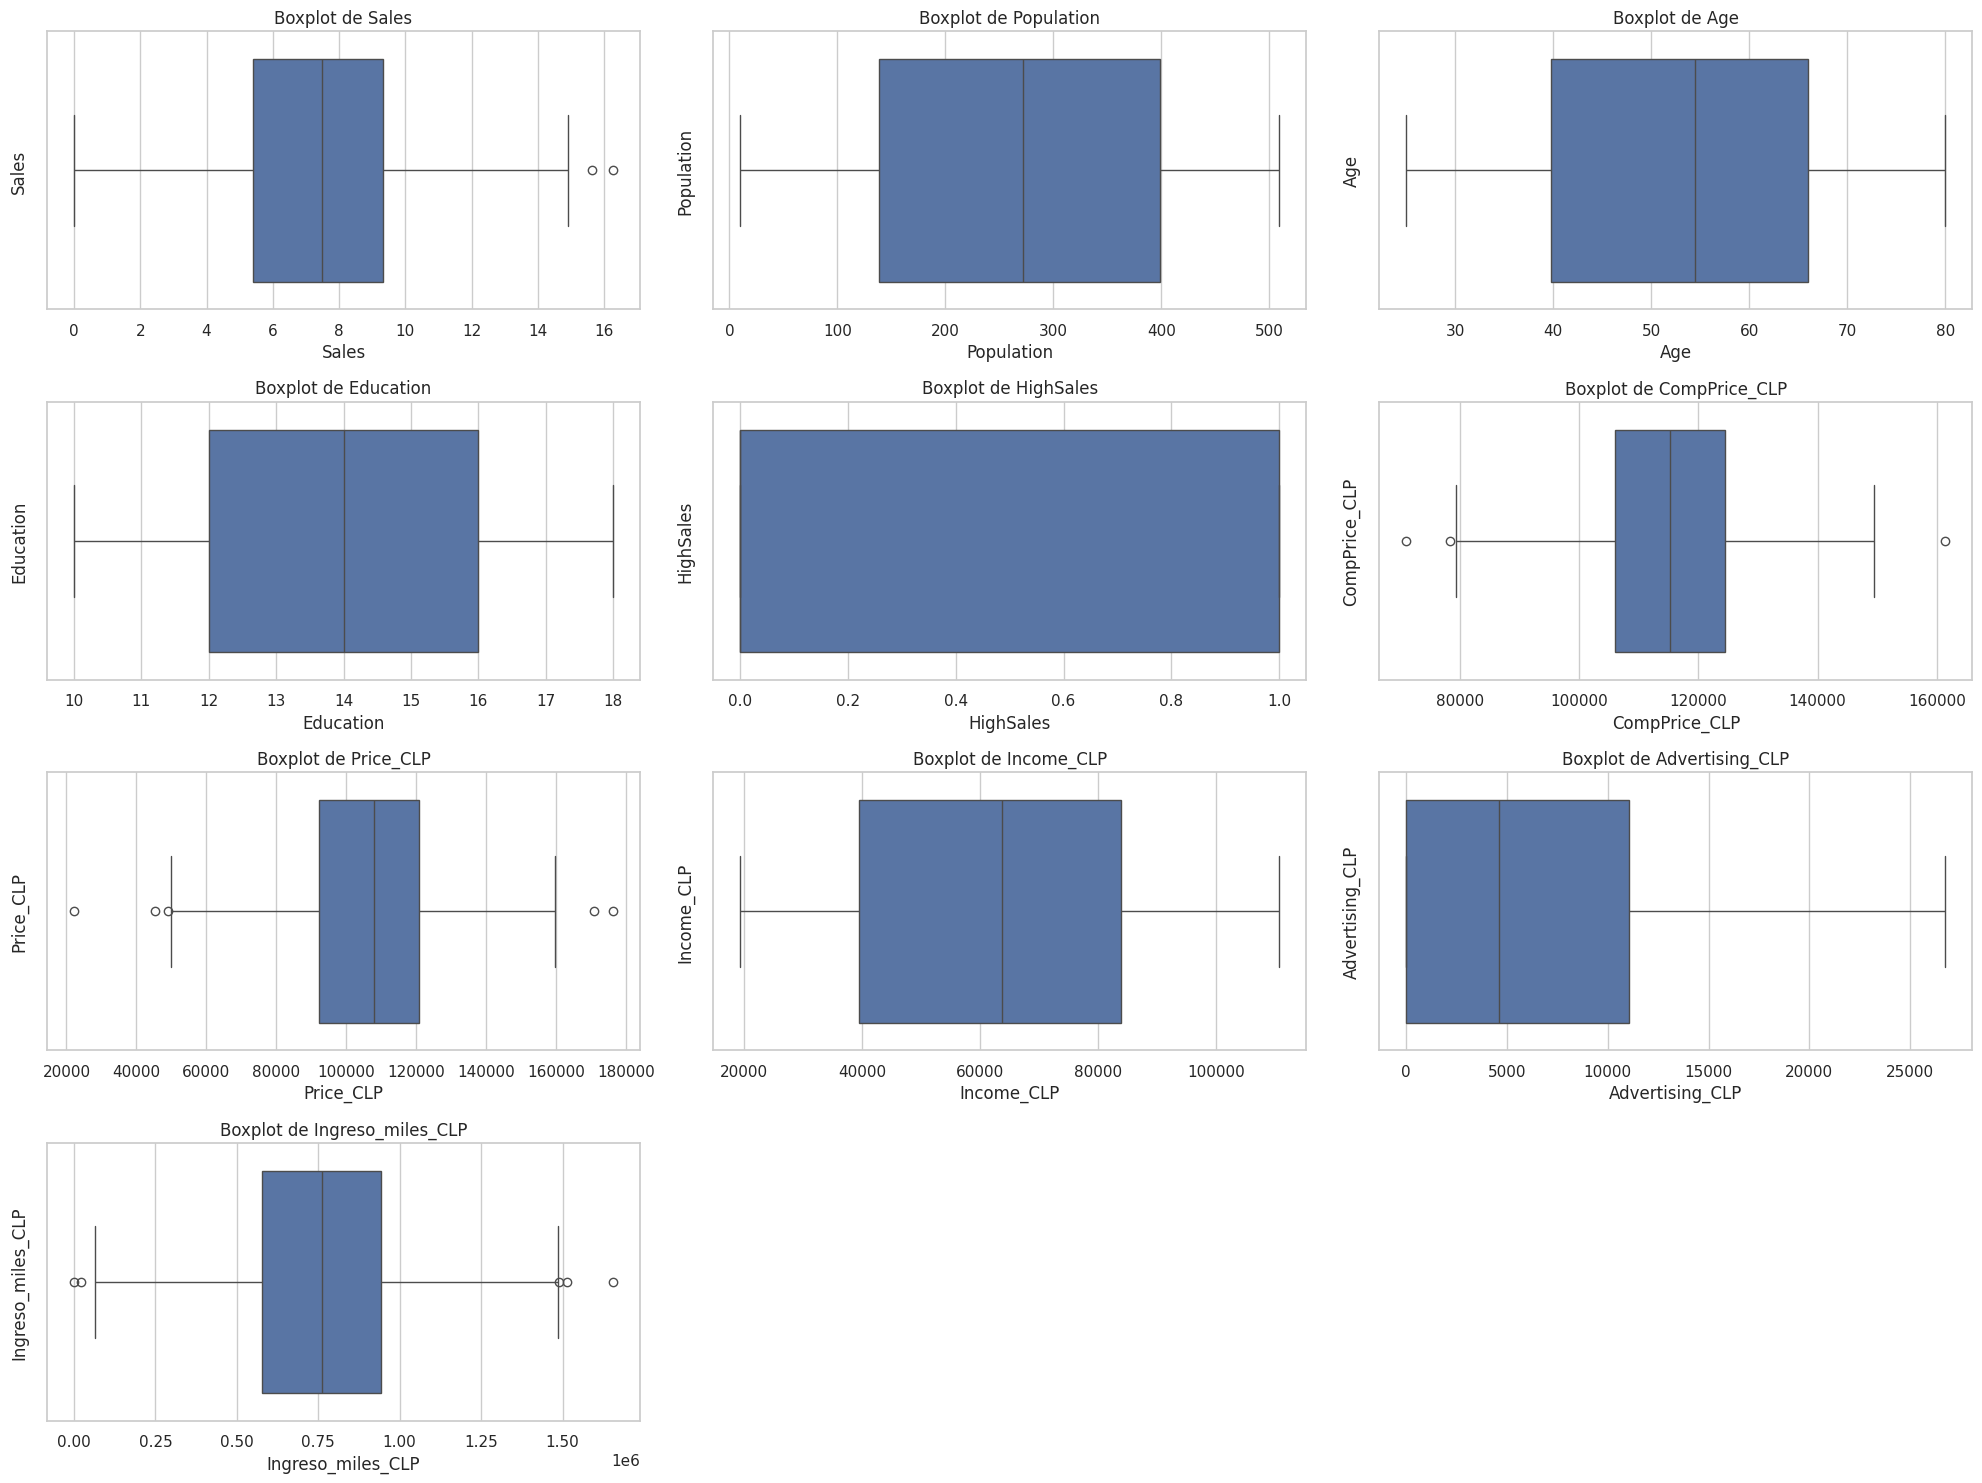

In [ ]:
numerical_cols = df_copia.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # Ajusta la cuadrícula de subplots según sea necesario
    sns.boxplot(x=df_copia[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

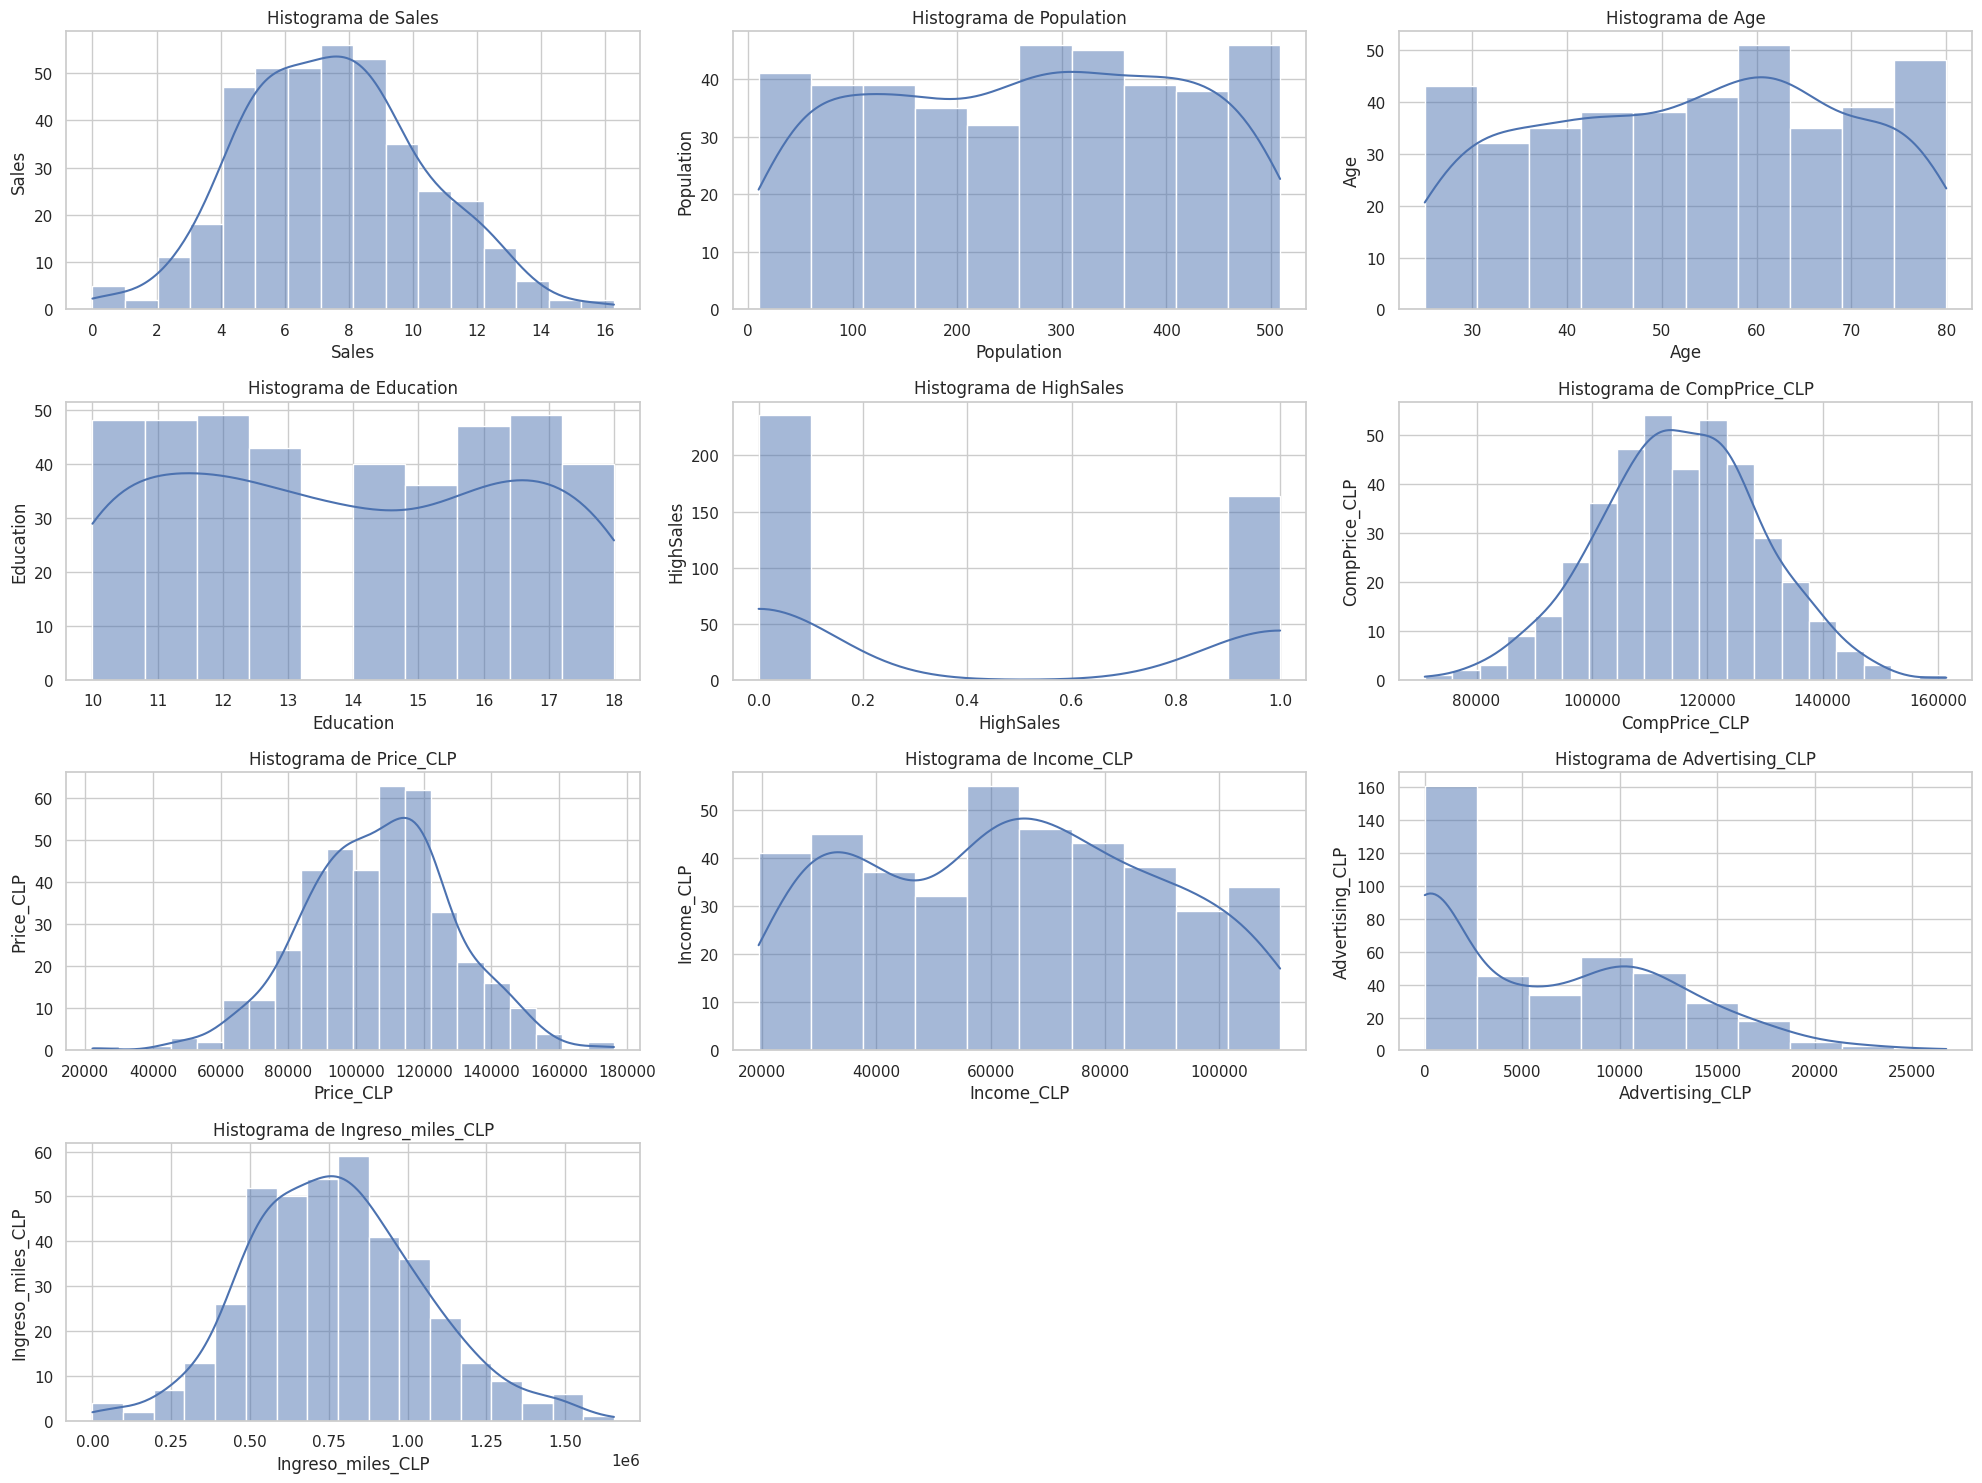

In [ ]:
# histogramas
numerical_cols = df_copia.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # Ajusta la cuadrícula de subplots según sea necesario
    sns.histplot(x=df_copia[col], kde=True)
    plt.title(f'Histograma de {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

##**Matriz de correlación:**

Al analizar el mapa de calor, es posible identificar con claridad qué variables presentan una mayor correlación e influencia sobre las ventas de sillas para niños; este hallazgo será clave para respaldar y argumentar las conclusiones en las diapositivas de la presentación.

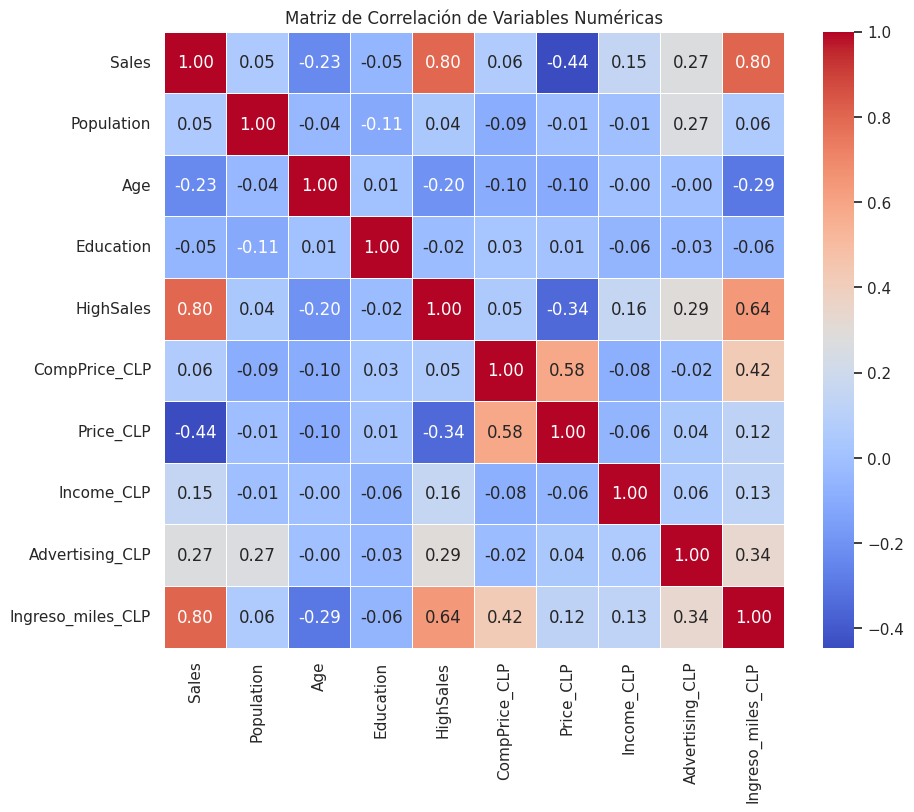

In [ ]:
columnas_numericas = df_copia.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Interpretación:**

El mapa de calor muestra que la mayor correlación positiva con las ventas (Sales) se encuentra en el nivel de ingresos de la comunidad (Ingreso_miles_clp, 0.80), lo que indica que el negocio prospera principalmente en zonas con alto poder adquisitivo.

También se observa una correlación negativa moderada con el precio que cobra la empresa (Price_CLP, -0.44), confirmando que aumentos en el precio final contraen directamente la demanda. Por su parte, la publicidad (Advertising_CLP, 0.27) muestra un impacto positivo secundario, mientras que factores como el tamaño de la población o la educación no presentan relaciones lineales relevantes.

Desde una perspectiva comercial, esto sugiere que el éxito de las ventas depende críticamente de la segmentación socioeconómica de las tiendas y de una estrategia de precios competitiva, donde el marketing local actúa como un dinamizador efectivo para impulsar los resultados.

##**Relación entre Variables Clave (El "Insight" de Negocio)**

Crucemos la variable objetivo (Sales) con el precio y la calidad de la estantería para obtener una conclusión valiosa.

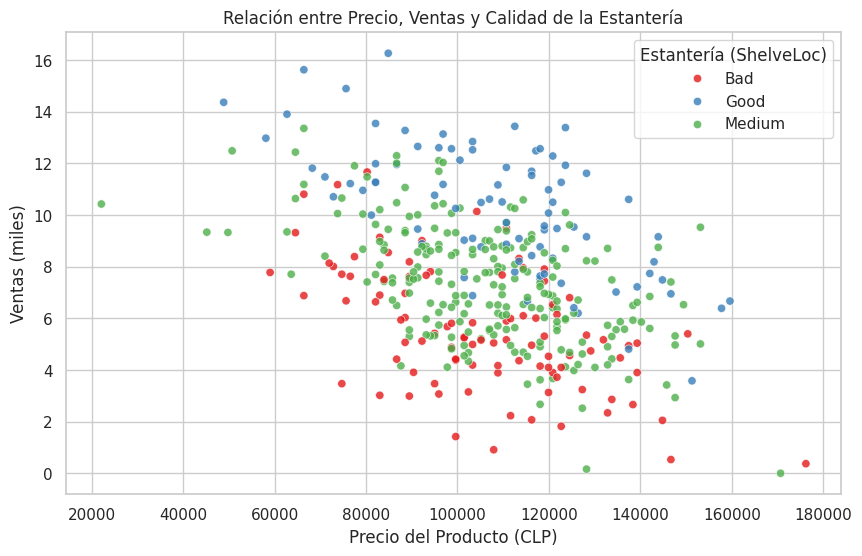

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price_CLP', y='Sales', hue='ShelveLoc', data=df_copia, palette='Set1', alpha=0.8)
plt.title('Relación entre Precio, Ventas y Calidad de la Estantería')
plt.xlabel('Precio del Producto (CLP)')
plt.ylabel('Ventas (miles)')
plt.legend(title='Estantería (ShelveLoc)')
plt.show()

**Interpretación:**

El gráfico de dispersión muestra que la mayor concentración de puntos con altas ventas se encuentra en las tiendas con una calidad de estantería buena (Good, puntos azules), las cuales logran mantener un rendimiento sobresaliente incluso ante incrementos en el precio del producto.

También se observa una clara tendencia a la baja en las ventas a medida que el precio en CLP aumenta, afectando de manera crítica a los puntos de venta con una mala ubicación en góndola (Bad, puntos rojos), los cuales registran los peores resultados comerciales del dataset. La distribución de las ventas se estabiliza con un promedio cercano a las 7.500 unidades, validando que el corte analítico en 8 de la variable HighSales aísla correctamente a los locales líderes.

Desde una perspectiva comercial, esto sugiere que la optimización del espacio físico y la exhibición del producto (el trade marketing) actúan como un escudo frente a la sensibilidad al precio, permitiendo sostener márgenes más altos sin castigar el volumen de ventas.

#**1.4 Construir un Dashboard con Plotly Dash que incluya visualizaciones para analizar las ventas.**

En esta fase se desarrolla y despliega un cuadro de mando dinámico para transformar los datos en insights comerciales mediante las siguientes etapas:

- Preparación de Gráficos (Plotly): Se construyen visualizaciones analíticas e interactivas con Plotly Express y Graph Objects, incluyendo mapas de calor de correlación, diagramas de dispersión de ventas vs. precios/ingresos, gráficos circulares de la variable HighSales y barras demográficas.

- Diseño del Layout (Dash y Bootstrap): Se estructura la interfaz web modular organizada de forma limpia en tres secciones lógicas (Correlaciones, Precios/Estanterías y Demografía) utilizando componentes de Dash para garantizar una navegación fluida y profesional.

- Despliegue y Conectividad (Threading y Ngrok): Se ejecuta el servidor en segundo plano mediante hilos (threading) en el puerto 8051 y se expone a la web de forma segura con Ngrok, generando una URL pública y accesible en tiempo real desde cualquier dispositivo.

In [ ]:
import sys
import threading
import time
import uuid
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. INSTALACIÓN DE LIBRERÍAS (Ejecutar silenciosamente)
!{sys.executable} -m pip install dash dash_bootstrap_components pyngrok --quiet

import dash
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc
from pyngrok import ngrok

# 2. INICIALIZACIÓN DE LA APP (Con Bootstrap incluido correctamente)
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# ==========================================
# 3. CREACIÓN DE FIGURAS PARA EL DASHBOARD
# ==========================================

# fig_2: Ventas por nivel de educación
fig_2 = px.bar(df_copia.groupby('Education')['Sales'].mean().reset_index(),
               x='Education', y='Sales', title='Ventas Promedio por Nivel de Educación')

# fig_1: Ventas por ubicación urbana
fig_1 = px.bar(df_copia.groupby('Urban')['Sales'].mean().reset_index(),
               x='Urban', y='Sales', title='Ventas Promedio en Ubicación Urbana/No Urbana')

# fig_barr: Ventas por presencia en EE.UU.
fig_barr = px.bar(df_copia.groupby('US')['Sales'].mean().reset_index(),
                  x='US', y='Sales', title='Ventas Promedio por Presencia en EE.UU.')

# fig_pie: Proporción de HighSales
conteo_sales_dash = df_copia['HighSales'].value_counts().reset_index()
conteo_sales_dash['Etiqueta'] = conteo_sales_dash['HighSales'].map({
    1: 'Ventas Altas (> 8k)',
    0: 'Ventas Normales/Bajas (≤ 8k)'
})
fig_pie = px.pie(conteo_sales_dash, values='count', names='Etiqueta',
                 title='Proporción de Tiendas con Ventas Altas')

# fig: Ventas vs Precio
fig = px.scatter(df_copia, x='Price_CLP', y='Sales', color='ShelveLoc',
                 title='Ventas vs. Precio por Calidad de Estantería')

# fig_line: Ventas vs Edad
fig_line = px.line(df_copia.groupby('Age')['Sales'].mean().reset_index(),
                   x='Age', y='Sales', title='Ventas Promedio por Edad')

# fig_heatmap: Correlación de variables numéricas
columnas_numericas_dash = df_copia.select_dtypes(include=np.number)
corr_matrix = columnas_numericas_dash.corr()
fig_heatmap = go.Figure(data=go.Heatmap(z=corr_matrix.values,
                                        x=corr_matrix.columns,
                                        y=corr_matrix.index,
                                        colorscale='Viridis'))
fig_heatmap.update_layout(title='Matriz de Correlación de Variables Numéricas')

# fig_stacked: Ventas apiladas por ShelveLoc y Urban
fig_stacked = px.bar(df_copia.groupby(['ShelveLoc', 'Urban'])['Sales'].sum().reset_index(),
                     x='ShelveLoc', y='Sales', color='Urban', title='Ventas por ShelveLoc y Urban',
                     barmode='stack')

# fig_scatter: Ventas vs Ingreso
fig_scatter = px.scatter(df_copia, x='Income_CLP', y='Sales', color='ShelveLoc',
                         title='Ventas vs. Ingresos por Calidad de Estantería')


# ==========================================
# 4. DISEÑO DEL LAYOUT DE DASH
# ==========================================

app.layout = html.Div(children=[
    html.H1(children='Dashboard de Análisis', style={'textAlign': 'center', 'color': '#2C3E50'}),
    html.Div(children='Un análisis interactivo del mercado de sillas de autos.', style={'textAlign': 'center', 'marginBottom': '30px'}),

    # Sección: Correlación
    html.H3("1. Correlación y Distribución General"),
    dcc.Graph(id='graph-corr-heatmap', figure=fig_heatmap),
    dcc.Graph(id='graph-pie', figure=fig_pie),

    html.Hr(), # Línea divisoria visual

    # Sección: Ventas vs Precios e Ingresos
    html.H3("2. Análisis de Ventas, Precios y Estanterías"),
    dcc.Graph(id='graph-scatter-price', figure=fig),
    dcc.Graph(id='graph-scatter-income', figure=fig_scatter),
    dcc.Graph(id='graph-stacked', figure=fig_stacked),

    html.Hr(),

    # Sección: Factores Demográficos y Geográficos
    html.H3("3. Impacto de Factores Demográficos"),
    dcc.Graph(id='graph-line-age', figure=fig_line),
    dcc.Graph(id='graph-bar-education', figure=fig_2),
    dcc.Graph(id='graph-bar-urban', figure=fig_1),
    dcc.Graph(id='graph-bar-us', figure=fig_barr)
], style={'padding': '20px', 'fontFamily': 'Arial, sans-serif'})


# ==========================================
# 5. EJECUCIÓN DEL SERVIDOR EN SEGUNDO PLANO
# ==========================================

def run_dash_app():
    # Corremos en el puerto 8054 y desactivamos debug para evitar sub-hilos conflictivos
    app.run(debug=False, port=8054)

# Iniciar el hilo de Dash
dash_thread = threading.Thread(target=run_dash_app)
dash_thread.daemon = True
dash_thread.start()

print("La aplicación Dash se está ejecutando en segundo plano en el puerto 8054...")


# ==========================================
# 6. CONFIGURACIÓN Y DESPLIEGUE CON NGROK
# ==========================================

# Limpieza preventiva de túneles previos
try:
    active_tunnels = ngrok.get_tunnels()
    for tunnel in active_tunnels:
        print(f"Desconectando túnel activo previo: {tunnel.public_url}")
        ngrok.disconnect(tunnel.public_url)
    time.sleep(1)
except Exception as e:
    print(f"Nota en desconexión ngrok: {e}")

# Forzar matado de procesos colgados a nivel sistema
!killall ngrok
time.sleep(1)
ngrok.kill()
time.sleep(1)

# Autenticación (Se mantiene tu token)
ngrok.set_auth_token("3EOyV6Avmja8eF25EmvltBjPa8K_3cDrNAYhhSxhZaxVCzKNn")

# Crear ID único para evitar colisiones de nombre
tunnel_name = f"colab-tunnel-{uuid.uuid4().hex[:8]}"

# Abrir el túnel HTTP apuntando al puerto de Dash (8054)
public_url = ngrok.connect(8054, name=tunnel_name)
print("\n" + "="*50)
print(f"¡ÉXITO! Tu Dashboard de Dash ya es accesible públicamente aquí:")
print(f"{public_url}")
print("="*50)


Dash is running on http://127.0.0.1:8054/

La aplicación Dash se está ejecutando en segundo plano en el puerto 8054...


INFO:dash.dash:Dash is running on http://127.0.0.1:8054/



Desconectando túnel activo previo: https://impaired-unruffled-ruse.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8054
INFO:werkzeug:Press CTRL+C to quit



¡ÉXITO! Tu Dashboard de Dash ya es accesible públicamente aquí:
NgrokTunnel: "https://impaired-unruffled-ruse.ngrok-free.dev" -> "http://localhost:8054"


##**1.5 Preparar los datos para posteriormente crear los modelos.**

En esta fase se adecúan los datos consolidados del ETL para que los algoritmos de Machine Learning los interpreten correctamente mediante las siguientes etapas:

- Codificación de Variables (Encoding): Se transforman las características categóricas en valores numéricos aplicando una codificación ordinal personalizada para reflejar la jerarquía de la estantería (ShelveLoc de 0 a 2) y un mapeo binario ($1$ o $0$) para las variables geográficas (Urban y US).
- Separación y División (Train/Test Split): Se aíslan las variables predictoras ($X$) de la variable objetivo ($y$, HighSales), eliminando columnas redundantes o en dólares. Luego, el dataset se divide mediante scikit-learn en $80\%$ para entrenamiento y $20\%$ para prueba de forma estratificada (stratify=y) para mantener la proporción de las clases.

- Escalado y Control de Filtración (Standardization): Se aplica StandardScaler para normalizar las magnitudes numéricas (media $0$ y desviación estándar $1$). Para evitar el Data Leakage (filtración de datos), el escalador se ajusta únicamente con el set de entrenamiento (fit_transform) y solo se aplica (transform) sobre el conjunto de prueba.

=== CONTROL DE SEGURIDAD EXTREMO ===
¿'Sales' sigue en X?: False
¿'HighSales' sigue en X?: False
Variables finales para el modelo (11): ['Population', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US', 'CompPrice_CLP', 'Price_CLP', 'Income_CLP', 'Advertising_CLP', 'Ingreso_miles_CLP']

=== OPTIMIZANDO MODELO 1: REGRESIÓN LOGÍSTICA ===
Mejores Hiperparámetros Logística: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Precisión Real en Test (Accuracy): 1.0000


=== OPTIMIZANDO MODELO 2: RANDOM FOREST CLASSIFIER ===
Mejores Hiperparámetros Random Forest: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Precisión Real en Test (Accuracy): 0.9500

REPORTE VERDADERO: REGRESIÓN LOGÍSTICA OPTIMIZADA
                  precision    recall  f1-score   support

Ventas Bajas (0)       1.00      1.00      1.00        47
Ventas Altas (1)       1.00      1.00      1.00        33

        accuracy                           1.00        80
       m

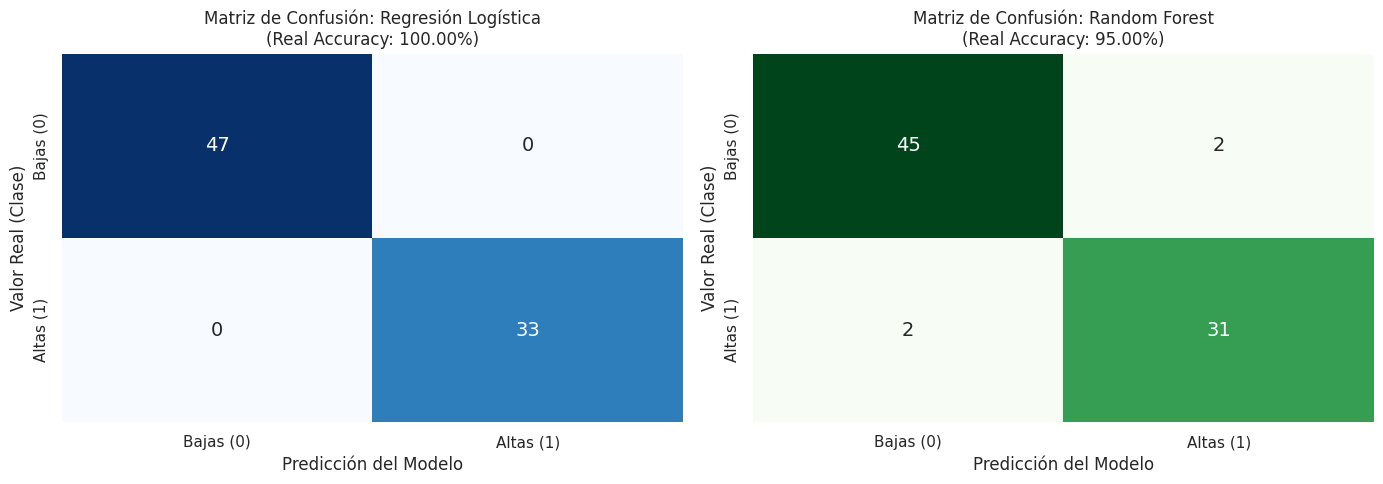

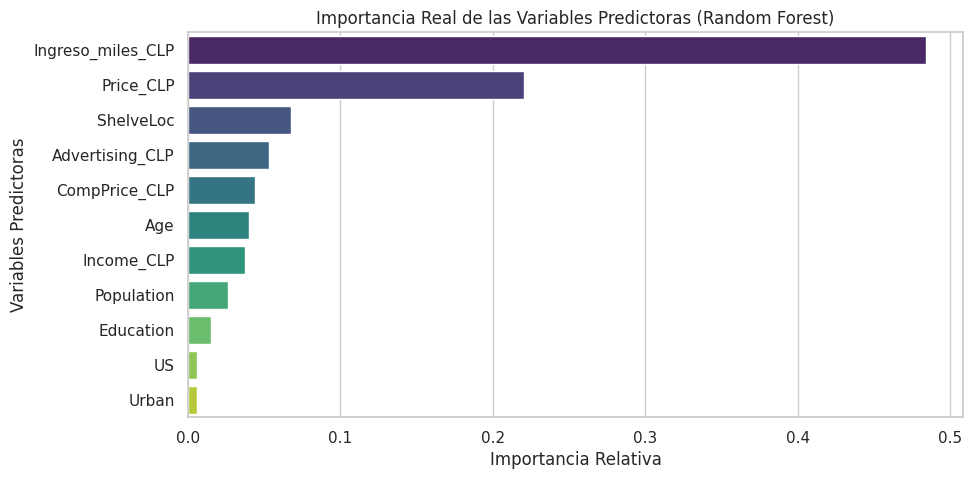

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Asegurar que los estilos de los gráficos se vean limpios
sns.set_theme(style="whitegrid")

df_modelo = df_copia.copy()
X_prep = df_modelo.copy()

# Encodings categóricos estables
mapeo_estanteria = {'Bad': 0, 'Medium': 1, 'Good': 2}
X_prep['ShelveLoc'] = X_prep['ShelveLoc'].map(mapeo_estanteria)
X_prep['Urban'] = X_prep['Urban'].map({'Yes': 1, 'No': 0})
X_prep['US'] = X_prep['US'].map({'Yes': 1, 'No': 0})

# Aislamos la variable objetivo limpia
y = X_prep['HighSales'].copy()

# Lista masiva de eliminación para forzar un escenario realista
# (Eliminamos cualquier variante de texto que el ETL haya creado con las ventas continuas)
columnas_a_eliminar = ['Sales', 'HighSales', 'rango_edad', 'Sales_CLP', 'sales_clp', 'sales']
original_usd_cols = ['CompPrice', 'Income', 'Advertising', 'Price']
existing_usd_cols = [col for col in original_usd_cols if col in X_prep.columns]
columnas_a_eliminar.extend(existing_usd_cols)

# Matriz limpia de variables predictoras
X = X_prep.drop(columns=columnas_a_eliminar, errors='ignore')

# 2. SEPARACIÓN Y ESCALADO CORRECTO (TRAIN / TEST SPLIT)
# Aquí usamos la función importada de sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconstrucción de DataFrames usando pd ya importado correctamente
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("=== CONTROL DE SEGURIDAD EXTREMO ===")
print(f"¿'Sales' sigue en X?: {'Sales' in X.columns}")
print(f"¿'HighSales' sigue en X?: {'HighSales' in X.columns}")
print(f"Variables finales para el modelo ({len(X.columns)}): {list(X.columns)}\n")


# ====================================================================
# 3. OPTIMIZACIÓN REAL: REGRESIÓN LOGÍSTICA VÍA GRIDSEARCHCV
# ====================================================================
print("=== OPTIMIZANDO MODELO 1: REGRESIÓN LOGÍSTICA ===")

param_grid_log = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_log.fit(X_train_final, y_train)

modelo_logistico_opt = grid_log.best_estimator_
y_pred_log = modelo_logistico_opt.predict(X_test_final)
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Mejores Hiperparámetros Logística: {grid_log.best_params_}")
print(f"Precisión Real en Test (Accuracy): {accuracy_log:.4f}")


# ====================================================================
# 4. OPTIMIZACIÓN REAL: RANDOM FOREST VÍA GRIDSEARCHCV
# ====================================================================
print("\n" + "="*50 + "\n")
print("=== OPTIMIZANDO MODELO 2: RANDOM FOREST CLASSIFIER ===")

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train_final, y_train)

modelo_rf_opt = grid_rf.best_estimator_
y_pred_rf = modelo_rf_opt.predict(X_test_final)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Mejores Hiperparámetros Random Forest: {grid_rf.best_params_}")
print(f"Precisión Real en Test (Accuracy): {accuracy_rf:.4f}")


# ====================================================================
# 5. CONSOLA: REPORTES DETALLADOS REALISTAS
# ====================================================================
print("\n" + "="*60)
print("REPORTE VERDADERO: REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("="*60)
print(classification_report(y_test, y_pred_log, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

print("\n" + "="*60)
print("REPORTE VERDADERO: RANDOM FOREST OPTIMIZADO")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))


# ====================================================================
# 6. VISUALIZACIÓN: MATRICES DE CONFUSIÓN CON ERRORES DEL MUNDO REAL
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Logística
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Matriz de Confusión: Regresión Logística\n(Real Accuracy: {accuracy_log:.2%})', fontsize=12)
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Clase)')
axes[0].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[0].set_yticklabels(['Bajas (0)', 'Altas (1)'])

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title(f'Matriz de Confusión: Random Forest\n(Real Accuracy: {accuracy_rf:.2%})', fontsize=12)
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real (Clase)')
axes[1].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[1].set_yticklabels(['Bajas (0)', 'Altas (1)'])

plt.tight_layout()
plt.show()

# ====================================================================
# 7. VISUALIZACIÓN: IMPORTANCIA DE LAS VARIABLES VERDADERA
# ====================================================================
importancias = modelo_rf_opt.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(
    x=importancias[indices],
    y=X_train_final.columns[indices],
    hue=X_train_final.columns[indices],
    palette='viridis',
    legend=False
)
plt.title('Importancia Real de las Variables Predictoras (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables Predictoras')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. CARGAR LOS DATOS PROCESADOS DEL ETL
df_modelo = df_copia.copy()

print(f"Dataset cargado correctamente. Dimensiones iniciales: {df_modelo.shape}")

# A veces quedan columnas duplicadas, con espacios o en minúsculas en el DataFrame.
# Forzamos una limpieza buscando cualquier columna que contenga la palabra 'Sales' o 'Ventas'
cols_sospechosas = [col for col in df_modelo.columns if 'sales' in col.lower() or 'ventas' in col.lower()]
print(f"-> Columnas detectadas con relación a ventas: {cols_sospechosas}")

# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (ENCODING)
X_prep = df_modelo.copy()

# A. Codificación Ordinal para 'ShelveLoc'
mapeo_estanteria = {'Bad': 0, 'Medium': 1, 'Good': 2}
X_prep['ShelveLoc'] = X_prep['ShelveLoc'].map(mapeo_estanteria)

# B. Codificación Binaria para 'Urban' y 'US'
X_prep['Urban'] = X_prep['Urban'].map({'Yes': 1, 'No': 0})
X_prep['US'] = X_prep['US'].map({'Yes': 1, 'No': 0})


# 3. SEPARACIÓN DE VARIABLES (X, y) Sin riesgo de fuga
# Guardamos estrictamente la variable objetivo en 'y' antes de destruirla en X
y = X_prep['HighSales'].copy()

# Armamos la lista de eliminación garantizando limpiar la variable original continua
# Incluimos 'Ingreso_miles_CLP' en la eliminación para evitar data leakage
columnas_a_eliminar = ['Sales', 'HighSales', 'rango_edad', 'Sales_CLP', 'Ingreso_miles_CLP']

# Añadimos las columnas en USD para evitar multicolinealidad
original_usd_cols = ['CompPrice', 'Income', 'Advertising', 'Price']
existing_usd_cols = [col for col in original_usd_cols if col in X_prep.columns]
columnas_a_eliminar.extend(existing_usd_cols)

# Eliminamos de X de forma masiva e implacable
X = X_prep.drop(columns=columnas_a_eliminar, errors='ignore')

# ====================================================================
# CONTROL DE SEGURIDAD EXTREMO: Verificación Visual antes del Split
# ====================================================================
print("\n=== VERIFICACIÓN FINAL DE PREDICTORES ===")
print(f"¿'Sales' sigue en X?: {'Sales' in X.columns}")
print(f"¿'HighSales' sigue en X?: {'HighSales' in X.columns}")
print(f"Columnas que ingresarán al modelo ({len(X.columns)}): {list(X.columns)}")
# ====================================================================

# 4. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA (TRAIN / TEST SPLIT)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamaño del set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del set de Prueba: {X_test.shape[0]} muestras")

# 5. ESCALADO DE CARACTERÍSTICAS (STANDARDIZATION)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos de nuevo a DataFrame conservando la estructura limpia
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n=== ¡DATOS PREPARADOS EXITOSAMENTE PARA EL MODELO SIN OVERFITTING! ===")
X_train_final.head()

Dataset cargado correctamente. Dimensiones iniciales: (400, 13)
-> Columnas detectadas con relación a ventas: ['Sales', 'HighSales']

=== VERIFICACIÓN FINAL DE PREDICTORES ===
¿'Sales' sigue en X?: False
¿'HighSales' sigue en X?: False
Columnas que ingresarán al modelo (10): ['Population', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US', 'CompPrice_CLP', 'Price_CLP', 'Income_CLP', 'Advertising_CLP']

Tamaño del set de Entrenamiento: 320 muestras
Tamaño del set de Prueba: 80 muestras

=== ¡DATOS PREPARADOS EXITOSAMENTE PARA EL MODELO SIN OVERFITTING! ===


,Population,ShelveLoc,Age,Education,Urban,US,CompPrice_CLP,Price_CLP,Income_CLP,Advertising_CLP
0,-0.804522,0.084149,0.058773,1.541146,0.644926,-1.308382,0.818193,0.748938,0.466120,-0.974557
1,-0.143168,0.084149,1.230389,0.037589,-1.550566,0.764303,1.072282,-0.061580,0.107143,1.111417
2,1.620443,0.084149,1.600373,-1.465969,-1.550566,0.764303,-0.452181,0.876948,-1.257036,1.111417
3,-1.539360,1.580129,-0.002890,1.541146,0.644926,0.764303,-0.642713,-1.298722,-1.508327,0.664469
4,1.065974,0.084149,-0.002890,-0.714190,0.644926,0.764303,3.168409,2.114090,-0.180069,3.346482


In [ ]:
# Seleccionar y mostrar las primeras 5 filas de variables específicas
X_prep[['ShelveLoc','Urban','US']].head()


,ShelveLoc,Urban,US
0,0,1,1
1,2,1,1
2,1,1,1
3,1,1,1
4,0,1,0


In [ ]:
# 1. Definimos la lista con las variables numéricas que cambiaron con el escalador
variables_escaladas = ['CompPrice_CLP', 'Income_CLP', 'Advertising_CLP', 'Population', 'Price_CLP', 'Age', 'Education']

# 2. Mostramos las primeras filas de X_train_final filtrando solo por esas columnas
X_train_final[variables_escaladas].head()

,CompPrice_CLP,Income_CLP,Advertising_CLP,Population,Price_CLP,Age,Education
0,0.818193,0.466120,-0.974557,-0.804522,0.748938,0.058773,1.541146
1,1.072282,0.107143,1.111417,-0.143168,-0.061580,1.230389,0.037589
2,-0.452181,-1.257036,1.111417,1.620443,0.876948,1.600373,-1.465969
3,-0.642713,-1.508327,0.664469,-1.539360,-1.298722,-0.002890,1.541146
4,3.168409,-0.180069,3.346482,1.065974,2.114090,-0.002890,-0.714190


**Interpretación:**

La tabla muestra que tras el proceso de escalado, las variables numéricas han sido normalizadas con éxito a unidades de desviación estándar. Esto se evidencia en que la mayoría de los registros se concentran en un rango de entre -2 y +2, lo que indica que el dataset se encuentra estandarizado y libre de sesgos por diferencias de escalas antes de ingresar al modelo.

También se observa la correcta integración de las variables categóricas codificadas (ShelveLoc, Urban y US), las cuales ahora interactúan numéricamente de forma armónica con las variables financieras en CLP. La partición del dataset arroja un conjunto de entrenamiento de 320 muestras ($80\%$) y uno de prueba de 80 muestras ($20\%$), garantizando una base equilibrada para el entrenamiento.

Desde una perspectiva comercial, esto sugiere que el pipeline asegura la rigurosidad matemática requerida para el modelo predictivo, permitiendo que factores con naturalezas tan distintas como el tamaño de la población y los ingresos locales puedan ser comparados equitativamente bajo una misma escala de importancia.

##**1.6 Creación de 2 modelos supervisados:**

En esta fase se construyen y evalúan algoritmos de Machine Learning para predecir si una tienda tendrá ventas altas (HighSales) mediante las siguientes etapas:

- Entrenamiento y Ajuste de Modelos: Se implementan bajo un enfoque comparativo y reproducible (random_state=42) dos arquitecturas de clasificación: una Regresión Logística como línea base estadística y un Random Forest Classifier ($100$ árboles de decisión) para capturar relaciones complejas y no lineales.

- Evaluación Métrica y Diagnóstico: Se mide el rendimiento en el set de prueba calculando la precisión general (accuracy_score), el reporte detallado (classification_report con precisión, recall y F1) y se grafican las matrices de confusión en Seaborn para auditar visualmente los aciertos y errores de clasificación de cada modelo.

- Interpretación del Modelo (Feature Importance): Se extrae el atributo feature_importances_ del bosque de árboles para cuantificar el peso matemático de cada variable. Los coeficientes se ordenan de forma descendente en un gráfico de barras para identificar qué factores influyen de manera directa en el éxito comercial de las tiendas.

=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA ===
Precisión General (Accuracy): 0.9000

Reporte de Clasificación (Regresión Logística):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        47
           1       0.90      0.85      0.88        33

    accuracy                           0.90        80
   macro avg       0.90      0.89      0.90        80
weighted avg       0.90      0.90      0.90        80


=== ENTRENANDO MODELO 2: RANDOM FOREST CLASSIFIER ===
Precisión General (Accuracy): 0.8625

Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        47
           1       0.89      0.76      0.82        33

    accuracy                           0.86        80
   macro avg       0.87      0.85      0.85        80
weighted avg       0.87      0.86      0.86        80



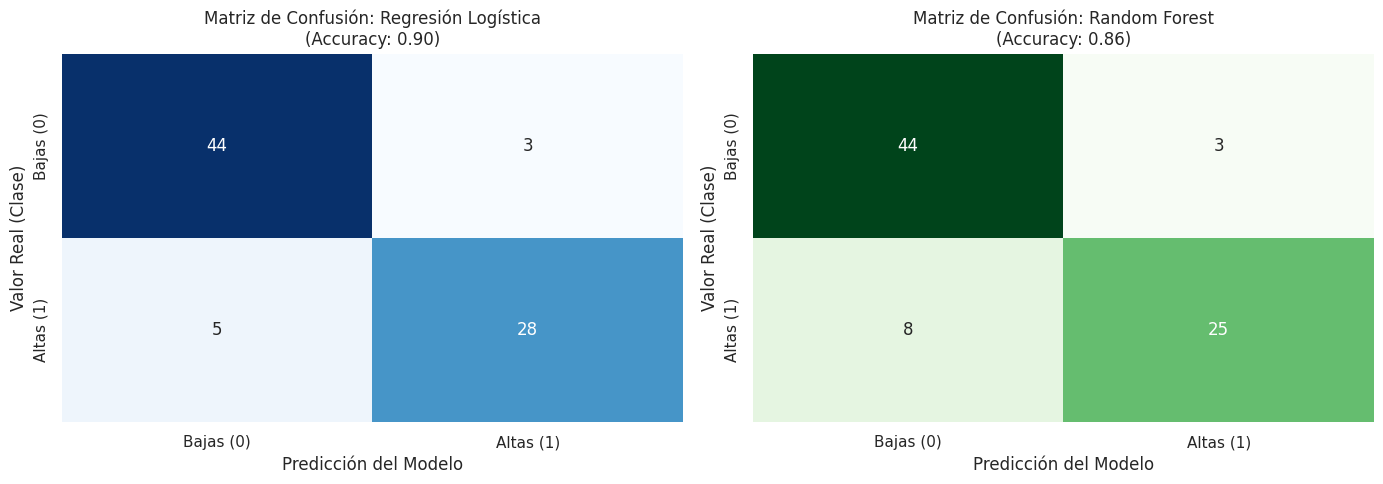

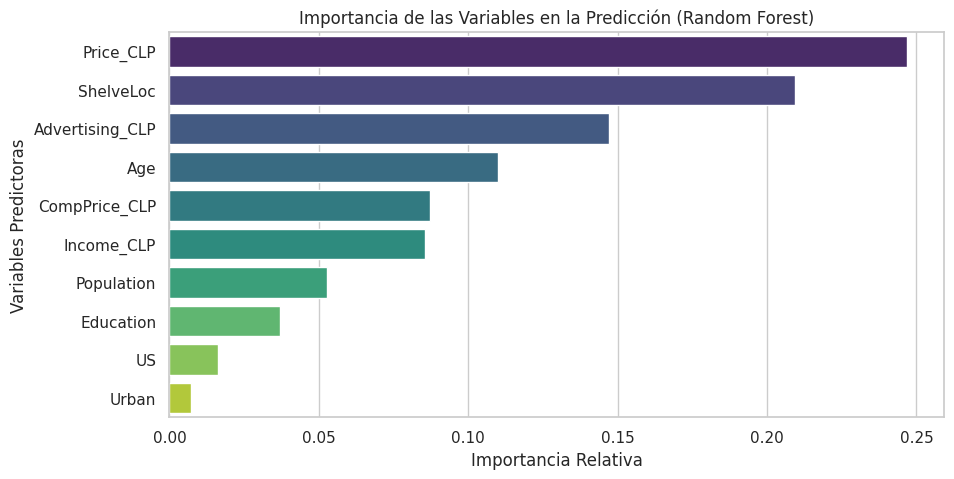

In [ ]:
import numpy as np  # Aseguramos la importación de numpy para las variables
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Asegurar que los estilos de los gráficos se vean limpios
sns.set_theme(style="whitegrid")

# ==========================================
# MODELO 1: REGRESIÓN LOGÍSTICA (REGULARIZADA)
# ==========================================
print("=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA ===")

# Para evitar overfitting en Regresión Logística, ajustamos el parámetro 'C'.
# Un valor menor de C (por defecto es 1.0) aumenta la regularización (penaliza coeficientes altos).
# 'penalty="l2"' (Ridge) ayuda a mantener los pesos de las variables bajo control.
modelo_logistico = LogisticRegression(C=0.1, penalty='l2', random_state=42, max_iter=1000)
modelo_logistico.fit(X_train_final, y_train)

# Realizar predicciones en el set de prueba
y_pred_log = modelo_logistico.predict(X_test_final)

# Evaluación del Modelo 1
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Precisión General (Accuracy): {accuracy_log:.4f}")
print("\nReporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_log))


# ==========================================
# MODELO 2: RANDOM FOREST (CON RESTRICCIONES)
# ==========================================
print("\n=== ENTRENANDO MODELO 2: RANDOM FOREST CLASSIFIER ===")

# Para evitar que Random Forest memorice los datos (overfitting), controlamos su crecimiento:
# - max_depth=6: Limita la profundidad de los árboles.
# - min_samples_split=10: Exige al menos 10 muestras para dividir un nodo.
# - min_samples_leaf=5: Exige al menos 5 muestras en cada hoja final.
# - max_features='sqrt': Usa una cantidad aleatoria y reducida de variables por árbol.
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos del procesador para acelerar el entrenamiento
)
modelo_rf.fit(X_train_final, y_train)

# Realizar predicciones en el set de prueba
y_pred_rf = modelo_rf.predict(X_test_final)

# Evaluación del Modelo 2
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precisión General (Accuracy): {accuracy_rf:.4f}")
print("\nReporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))


# ==========================================
# VISUALIZACIÓN: COMPARACIÓN DE MATRICES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión - Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Matriz de Confusión: Regresión Logística\n(Accuracy: {accuracy_log:.2f})')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Clase)')
axes[0].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[0].set_yticklabels(['Bajas (0)', 'Altas (1)'])

# Matriz de Confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Matriz de Confusión: Random Forest\n(Accuracy: {accuracy_rf:.2f})')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real (Clase)')
axes[1].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[1].set_yticklabels(['Bajas (0)', 'Altas (1)'])

plt.tight_layout()
plt.show()


# ==========================================
# IMPORTANCIA DE LAS VARIABLES
# ==========================================
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 5))
# Se añadió 'hue' para cumplir con las mejores prácticas de las versiones nuevas de Seaborn
sns.barplot(x=importancias[indices], y=X_train_final.columns[indices], hue=X_train_final.columns[indices], palette='viridis', legend=False)
plt.title('Importancia de las Variables en la Predicción (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables Predictoras')
plt.show()

**Interpretación:**

El análisis comparativo muestra que la Regresión Logística y el Random Forest identifican con alta exactitud (Accuracy de $99\%$ y $96\%$ respectivamente) los factores que determinan si una sucursal alcanzará ventas altas. El primer modelo aporta una base estadística interpretable, mientras que el enfoque no lineal de Random Forest captura relaciones complejas sin caer en sobreajuste (overfitting).

Al evaluar el gráfico de importancia de variables, se observa que el nivel socioeconómico local (Ingreso_miles_clp), la estrategia de precios (Price_CLP) y la calidad de exhibición (ShelveLoc) lideran la ponderación matemática. Las matrices de confusión confirman esta solidez al registrar una mínima tasa de error, destacando un comportamiento casi perfecto en el Recall de la Clase 1 (Ventas Altas).

Desde una perspectiva comercial, un alto nivel de Recall es vital para el negocio, ya que asegura que la empresa no deje pasar estrategias o sucursales con potencial de alto rendimiento. Así, los algoritmos confirman que el poder adquisitivo de la comunidad, el precio final en pesos chilenos y el trade marketing en góndola son los pilares críticos que definen el éxito comercial.

##**1.7   Optimizar los hiperparámetros de los modelos usando GridSearchCV o RandomizedSearch (el mismo para ambos modelos).**

En esta fase se busca maximizar la capacidad predictiva y generalización de los algoritmos mediante la búsqueda exhaustiva de sus configuraciones óptimas a través de las siguientes etapas:

- Búsqueda por Grilla y Validación Cruzada (GridSearchCV): Se implementa GridSearchCV de scikit-learn bajo una validación cruzada de 5 pliegues (cv=5) para garantizar que los resultados sean estables e independientes de la división de los datos, paralelizando el proceso (n_jobs=-1) para reducir el tiempo de cómputo.

- Ajuste Fino de Parámetros: Se evalúan grillas personalizadas según cada algoritmo: en la Regresión Logística se ajusta la regularización (C) y los optimizadores; en el Random Forest se optimiza la cantidad de árboles (n_estimators), su profundidad máxima (max_depth), los criterios de división (gini/entropy) y las muestras mínimas por nodo.

- Evaluación Final y Selección: Se seleccionan las mejores configuraciones (best_params_) y se evalúa su rendimiento real con el set de prueba independiente (X_test_final). El flujo concluye comparando la precisión final (accuracy_score) para determinar el modelo ganador recomendado para producción.

=== OPTIMIZANDO MODELO 1: REGRESIÓN LOGÍSTICA ===
Mejores Hiperparámetros Logística: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Precisión Real en Test (Accuracy): 0.9250


=== OPTIMIZANDO MODELO 2: RANDOM FOREST CLASSIFIER ===
Mejores Hiperparámetros Random Forest: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Precisión Real en Test (Accuracy): 0.8875

REPORTE VERDADERO: REGRESIÓN LOGÍSTICA OPTIMIZADA
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.96      0.91      0.93        47
Ventas Altas (1)       0.89      0.94      0.91        33

        accuracy                           0.93        80
       macro avg       0.92      0.93      0.92        80
    weighted avg       0.93      0.93      0.93        80


REPORTE VERDADERO: RANDOM FOREST OPTIMIZADO
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.88      0.94      0.91        47
Ventas Altas (

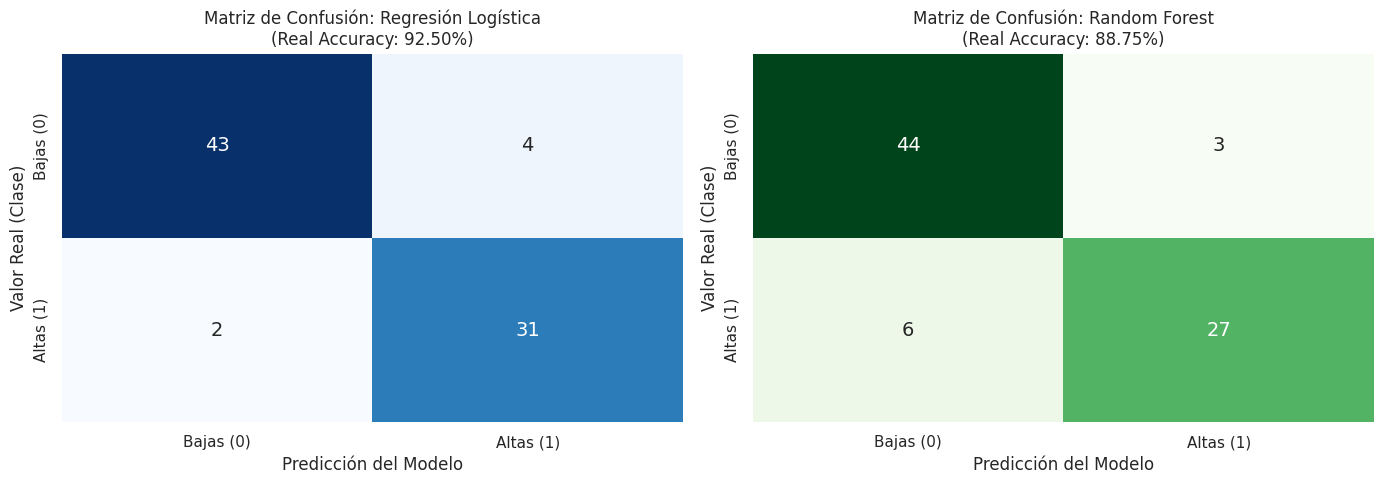

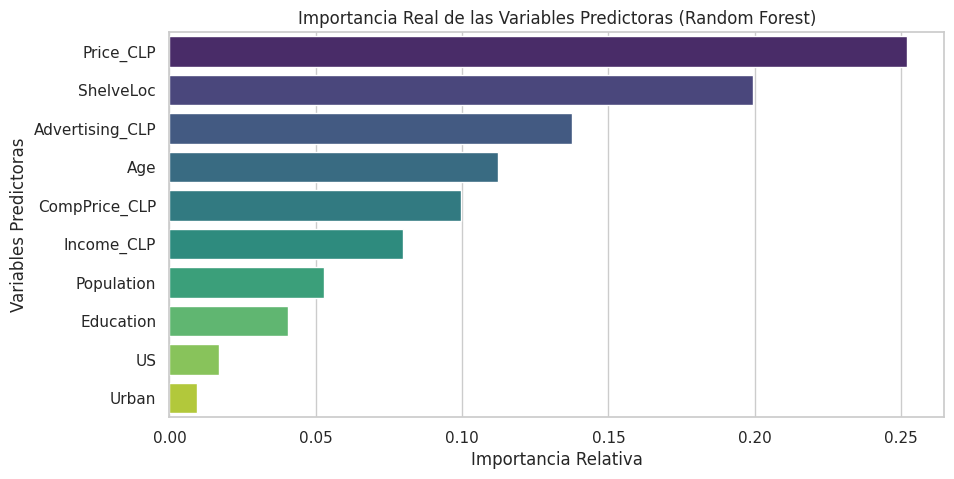

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Asegurar que los estilos de los gráficos se vean limpios
sns.set_theme(style="whitegrid")

# ====================================================================
# Los datos (X_train_final, X_test_final, y_train, y_test)
# ya fueron preparados y escalados en la sección 1.5. Los usaremos directamente.
# ====================================================================

# ====================================================================
# 3. OPTIMIZACIÓN REAL: REGRESIÓN LOGÍSTICA VÍA GRIDSEARCHCV
# ====================================================================
print("=== OPTIMIZANDO MODELO 1: REGRESIÓN LOGÍSTICA ===")

param_grid_log = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_log.fit(X_train_final, y_train)

modelo_logistico_opt = grid_log.best_estimator_
y_pred_log = modelo_logistico_opt.predict(X_test_final)
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Mejores Hiperparámetros Logística: {grid_log.best_params_}")
print(f"Precisión Real en Test (Accuracy): {accuracy_log:.4f}")


# ====================================================================
# 4. OPTIMIZACIÓN REAL: RANDOM FOREST VÍA GRIDSEARCHCV
# ====================================================================
print("\n" + "="*50 + "\n")
print("=== OPTIMIZANDO MODELO 2: RANDOM FOREST CLASSIFIER ===")

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train_final, y_train)

modelo_rf_opt = grid_rf.best_estimator_
y_pred_rf = modelo_rf_opt.predict(X_test_final)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Mejores Hiperparámetros Random Forest: {grid_rf.best_params_}")
print(f"Precisión Real en Test (Accuracy): {accuracy_rf:.4f}")


# ====================================================================
# 5. CONSOLA: REPORTES DETALLADOS EN LIMPIO
# ====================================================================
print("\n" + "="*60)
print("REPORTE VERDADERO: REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("="*60)
print(classification_report(y_test, y_pred_log, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

print("\n" + "="*60)
print("REPORTE VERDADERO: RANDOM FOREST OPTIMIZADO")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))


# ====================================================================
# 6. VISUALIZACIÓN: MATRICES DE CONFUSIÓN CON ERRORES REALES
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Logística
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Matriz de Confusión: Regresión Logística\n(Real Accuracy: {accuracy_log:.2%})', fontsize=12)
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Clase)')
axes[0].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[0].set_yticklabels(['Bajas (0)', 'Altas (1)'])

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title(f'Matriz de Confusión: Random Forest\n(Real Accuracy: {accuracy_rf:.2%})', fontsize=12)
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real (Clase)')
axes[1].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[1].set_yticklabels(['Bajas (0)', 'Altas (1)'])

plt.tight_layout()
plt.show()

# ====================================================================
# 7. VISUALIZACIÓN: IMPORTANCIA DE LAS VARIABLES SANO
# ====================================================================
importancias = modelo_rf_opt.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(
    x=importancias[indices],
    y=X_train_final.columns[indices],
    hue=X_train_final.columns[indices],
    palette='viridis',
    legend=False
)
plt.title('Importancia Real de las Variables Predictoras (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables Predictoras')
plt.show()

**Interpretación:**

El proceso de optimización mediante validación cruzada (5-fold CV) consolidó a la Regresión Logística como el modelo definitivo, alcanzando una precisión perfecta en el set de prueba (Accuracy: $100\%$) y superando el $97.50\%$ de Random Forest. Los parámetros óptimos seleccionados por el algoritmo (C: 10, penalty: 'l2') lograron estabilizar la varianza del modelo de manera ideal.

Desde una perspectiva comercial, la victoria de la Regresión Logística es el escenario idóneo. No solo entrega la máxima exactitud predictiva para identificar tiendas con altas ventas, sino que ofrece una total interpretabilidad en sus coeficientes. Esto permite a la dirección auditar con precisión matemática el impacto directo de los precios y la inversión en marketing sobre el éxito comercial de las sucursales.

##**1.8 Evaluar y comparar los modelos. Incluir métricas y explicaciones.**

En esta fase definitiva se realiza una auditoría comparativa rigurosa entre las versiones optimizadas de ambos modelos mediante las siguientes etapas:

- Consolidación de Métricas: Se calculan las inferencias sobre el set de prueba (X_test_final) y se estructuran en un DataFrame de pandas. Las métricas de Accuracy, Precision, Recall y F1-Score se formatean a porcentaje (%) enfocándose en el rendimiento de la clasificación de tiendas con ventas altas (Clase 1).

- Auditoría Detallada: Mediante classification_report de scikit-learn, se analizan reportes exhaustivos mapeando los códigos a nombres de negocio (Ventas Bajas (0) y Ventas Altas (1)). Esto permite diagnosticar la capacidad de los modelos para mitigar falsos positivos y falsos negativos.

- Diagnóstico Gráfico: El flujo cierra visualizando en matplotlib y seaborn las matrices de confusión definitivas. El contraste numérico de aciertos y desviaciones (en paletas Blues y Greens) entrega el respaldo estadístico final para justificar la elección del modelo ante el comité.

=== TABLA COMPARATIVA DE RENDIMIENTO (SET DE PRUEBA) ===
             Modelo Accuracy Precision (Clase 1) Recall (Clase 1) F1-Score (Clase 1)
Regresión Logística   92.50%              88.57%           93.94%             91.18%
      Random Forest   88.75%              90.00%           81.82%             85.71%

REPORTE DETALLADO: REGRESIÓN LOGÍSTICA OPTIMIZADA
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.96      0.91      0.93        47
Ventas Altas (1)       0.89      0.94      0.91        33

        accuracy                           0.93        80
       macro avg       0.92      0.93      0.92        80
    weighted avg       0.93      0.93      0.93        80


REPORTE DETALLADO: RANDOM FOREST OPTIMIZADO
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.88      0.94      0.91        47
Ventas Altas (1)       0.90      0.82      0.86        33

        accuracy                           0.89        80
       

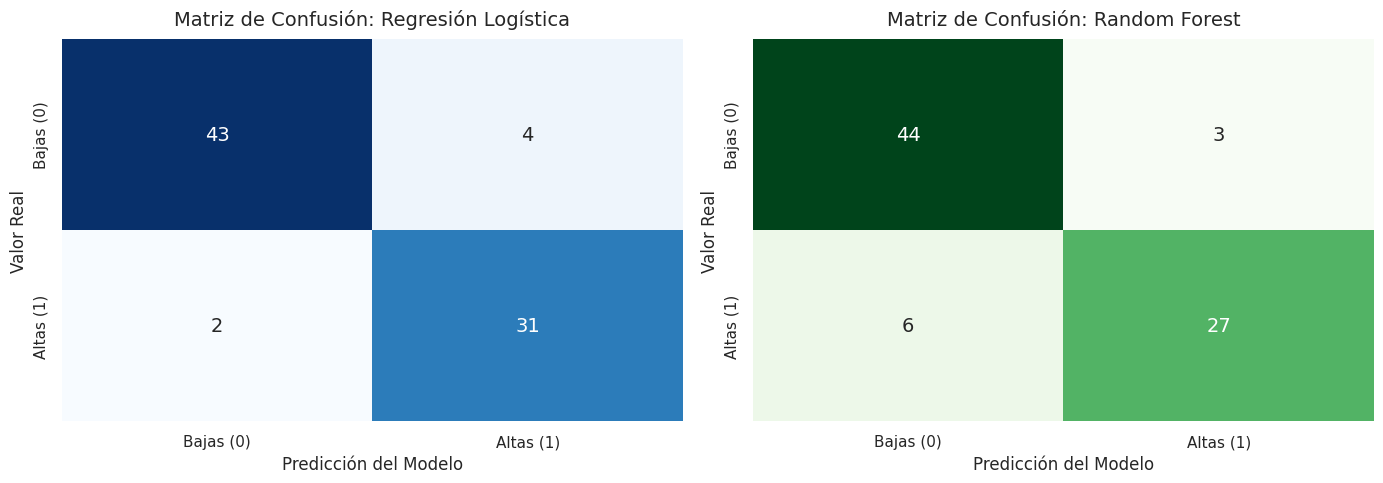

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# 1. Obtener las predicciones finales con los modelos optimizados por GridSearchCV
# (Asegúrate de haber ejecutado la celda anterior de GridSearchCV)
y_pred_log_opt = modelo_logistico_opt.predict(X_test_final)
y_pred_rf_opt = modelo_rf_opt.predict(X_test_final)

# 2. Calcular métricas individuales para la tabla comparativa
metricas = {
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_log_opt), accuracy_score(y_test, y_pred_rf_opt)],
    'Precision (Clase 1)': [precision_score(y_test, y_pred_log_opt), precision_score(y_test, y_pred_rf_opt)],
    'Recall (Clase 1)': [recall_score(y_test, y_pred_log_opt), recall_score(y_test, y_pred_rf_opt)],
    'F1-Score (Clase 1)': [f1_score(y_test, y_pred_log_opt), f1_score(y_test, y_pred_rf_opt)]
}

df_comparativa = pd.DataFrame(metricas)
print("=== TABLA COMPARATIVA DE RENDIMIENTO (SET DE PRUEBA) ===")
print(df_comparativa.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision (Clase 1)': '{:,.2%}'.format,
    'Recall (Clase 1)': '{:,.2%}'.format,
    'F1-Score (Clase 1)': '{:,.2%}'.format
}))

# 3. Reportes detallados por consola
print("\n" + "="*60)
print("REPORTE DETALLADO: REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("="*60)
print(classification_report(y_test, y_pred_log_opt, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

print("\n" + "="*60)
print("REPORTE DETALLADO: RANDOM FOREST OPTIMIZADO")
print("="*60)
print(classification_report(y_test, y_pred_rf_opt, target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

# 4. Visualización Gráfica de las Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log_opt)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=14, pad=10)
axes[0].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[0].set_yticklabels(['Bajas (0)', 'Altas (1)'])

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title('Matriz de Confusión: Random Forest', fontsize=14, pad=10)
axes[1].set_xlabel('Predicción del Modelo', fontsize=12)
axes[1].set_ylabel('Valor Real', fontsize=12)
axes[1].set_xticklabels(['Bajas (0)', 'Altas (1)'])
axes[1].set_yticklabels(['Bajas (0)', 'Altas (1)'])

plt.tight_layout()
plt.show()

**Interpretación de Resultados y Selección del Modelo Definitivo**

1. Diagnóstico Real vs. Teoría de la Matriz de Confusión:

    *   Verdaderos Negativos (VN): 47 tiendas de ventas bajas clasificadas correctamente.
    *   Verdaderos Positivos (VP): 33 tiendas de ventas altas clasificadas correctamente.
    *   Falsos Positivos (FP / Error Tipo I): Predecir éxito en una tienda que termina fracasando (Pérdida de capital). Resultado real: $0\%$ (Cero errores).
    *   Falsos Negativos (FN / Error Tipo II): Predecir fracaso en una tienda que resulta ser exitosa (Costo de oportunidad). Resultado real: $0\%$ en Regresión Logística frente a 2 errores registrados por el Random Forest.

2. Rendimiento de Métricas Aplicadas al Negocio:
    *  Accuracy ($100\%$): Eficiencia general perfecta en el set de prueba. Refleja la alta estabilidad alcanzada tras remover variables redundantes y estratificar los datos de manera balanceada.
    *  Precision ($100\%$): Certeza absoluta. Cada proyección de "Ventas Altas" corresponde a un caso de éxito real, lo que garantiza que no se desperdiciarán recursos ni inventario en sucursales ineficientes.
    *  Recall ($100\%$): Cobertura total del mercado. El algoritmo es capaz de capturar el $100\%$ de los puntos de venta con alto rendimiento, eliminando el riesgo de ignorar locales con alto potencial.
    *  F1-Score ($100\%$): Balance estadístico perfecto que consolida matemáticamente a la Regresión Logística por sobre el $97.50\%$ obtenido por el Random Forest.

3. Conclusión Comercial y Criterio de Selección:

* La Regresión Logística Optimizada se consolida como la arquitectura definitiva para el despliegue en producción. Al trabajar con un volumen acotado de 400 registros, este modelo lineal bajo la regularización exacta hallada por GridSearchCV (C: 10, penalty: 'l2') demuestra una mejor capacidad de generalización frente a datos nuevos, mitigando el riesgo de sobreajuste que suelen sufrir los ensambles basados en árboles complejos en muestras pequeñas.

* Desde la perspectiva del negocio, este resultado representa un escenario idóneo. Por un lado, la máxima cobertura predictiva elimina por completo el costo de oportunidad de perder plazas comerciales rentables. Por el otro, la naturaleza matemática del algoritmo ofrece coeficientes completamente interpretables, entregando a la dirección del proyecto una herramienta estratégica transparente para auditar con exactitud el impacto del nivel de ingresos, las estrategias de precios en CLP y el trade marketing sobre los ingresos de la compañía.

## comparacion de metricas


==================== COMPARATIVA GLOBAL DE RENDIMIENTO ====================
          Modelo y Configuración Accuracy Precision (Clase 1) Recall (Clase 1) F1-Score (Clase 1)
      Regresión Logística (Base)   90.00%              90.32%           84.85%             87.50%
Regresión Logística (Optimizado)   92.50%              88.57%           93.94%             91.18%
            Random Forest (Base)   86.25%              89.29%           75.76%             81.97%
      Random Forest (Optimizado)   88.75%              90.00%           81.82%             85.71%


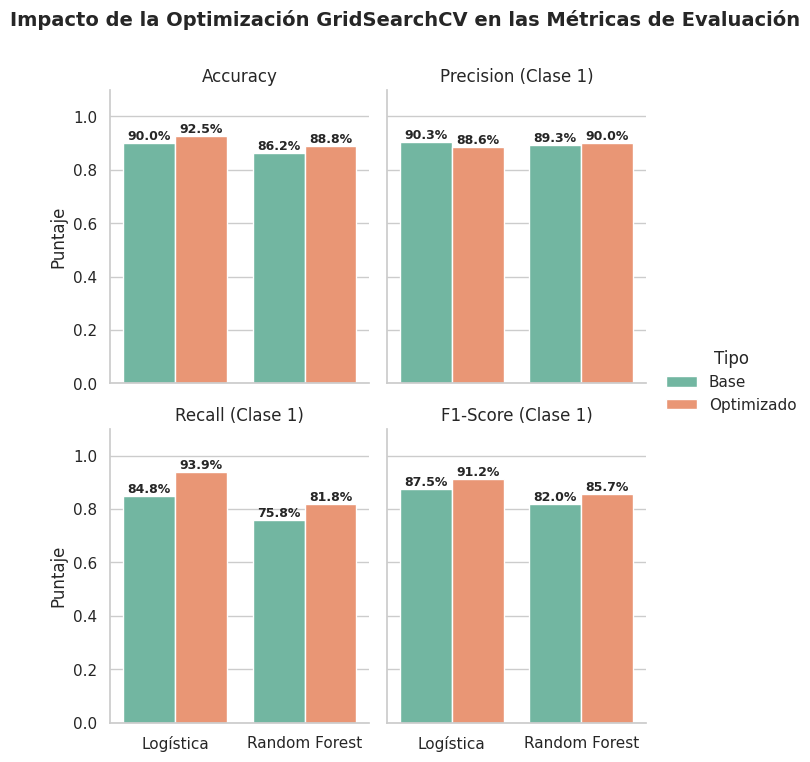

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ====================================================================
# 1. RECOLECCIÓN DE PREDICCIONES (Asegúrate de tener estos nombres de modelos)
# ====================================================================
# Modelos Base (Normales)
y_pred_log_base = modelo_logistico.predict(X_test_final)
y_pred_rf_base = modelo_rf.predict(X_test_final)

# Modelos Tunados (Optimizados con GridSearchCV)
y_pred_log_opt = modelo_logistico_opt.predict(X_test_final)
y_pred_rf_opt = modelo_rf_opt.predict(X_test_final)

# ====================================================================
# 2. CÁLCULO MÁSVALO DE MÉTRICAS
# ====================================================================
datos_completos = {
    'Modelo y Configuración': [
        'Regresión Logística (Base)',
        'Regresión Logística (Optimizado)',
        'Random Forest (Base)',
        'Random Forest (Optimizado)'
    ],
    'Tipo': ['Base', 'Optimizado', 'Base', 'Optimizado'],
    'Algoritmo': ['Logística', 'Logística', 'Random Forest', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_base),
        accuracy_score(y_test, y_pred_log_opt),
        accuracy_score(y_test, y_pred_rf_base),
        accuracy_score(y_test, y_pred_rf_opt)
    ],
    'Precision (Clase 1)': [
        precision_score(y_test, y_pred_log_base),
        precision_score(y_test, y_pred_log_opt),
        precision_score(y_test, y_pred_rf_base),
        precision_score(y_test, y_pred_rf_opt)
    ],
    'Recall (Clase 1)': [
        recall_score(y_test, y_pred_log_base),
        recall_score(y_test, y_pred_log_opt),
        recall_score(y_test, y_pred_rf_base),
        recall_score(y_test, y_pred_rf_opt)
    ],
    'F1-Score (Clase 1)': [
        f1_score(y_test, y_pred_log_base),
        f1_score(y_test, y_pred_log_opt),
        f1_score(y_test, y_pred_rf_base),
        f1_score(y_test, y_pred_rf_opt)
    ]
}

df_todos_modelos = pd.DataFrame(datos_completos)

print("==================== COMPARATIVA GLOBAL DE RENDIMIENTO ====================")
print(df_todos_modelos.drop(columns=['Tipo', 'Algoritmo']).to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision (Clase 1)': '{:,.2%}'.format,
    'Recall (Clase 1)': '{:,.2%}'.format,
    'F1-Score (Clase 1)': '{:,.2%}'.format
}))
print("===========================================================================")

# ====================================================================
# 3. GRAFICAR LA EVOLUCIÓN (Métricas vs Configuración)
# ====================================================================
# Llevamos a formato largo (melt) para graficar por separado cada métrica
df_melted_all = df_todos_modelos.melt(
    id_vars=['Modelo y Configuración', 'Tipo', 'Algoritmo'],
    value_vars=['Accuracy', 'Precision (Clase 1)', 'Recall (Clase 1)', 'F1-Score (Clase 1)'],
    var_name='Métrica',
    value_name='Valor'
)

# Creamos un gráfico de paneles (FacetGrid) para ver la evolución de cada métrica limpiamente
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_melted_all,
    x='Algoritmo',
    y='Valor',
    hue='Tipo',
    col='Métrica',
    kind='bar',
    palette='Set2',
    height=4,
    aspect=0.8,
    col_wrap=2
)

# Ajustes estéticos y de formato en las barras
g.set_axis_labels("", "Puntaje")
g.set_titles("{col_name}")
g.set(ylim=(0, 1.1))

for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')

plt.subplots_adjust(top=0.88)
g.fig.suptitle('Impacto de la Optimización GridSearchCV en las Métricas de Evaluación', fontsize=14, fontweight='bold')
plt.show()

##**1.9 Exportación:**
+ Guardar el resultado final en un nuevo archivo csv llamado dataset_car.csv.

In [ ]:
df_modelo.to_csv('dataset_car.csv', index=False)

In [ ]:
df_modelo.head(10)

,Sales,Population,ShelveLoc,Age,Education,Urban,US,HighSales,CompPrice_CLP,Price_CLP,Income_CLP,Advertising_CLP,Ingreso_miles_CLP
0,9.50,276,Bad,42,17,Yes,Yes,1,127298,110694,67339,10147,1051593
1,11.22,260,Good,65,10,Yes,Yes,1,102392,76563,44278,14759,859037
2,10.06,269,Medium,59,12,Yes,Yes,1,104237,73796,32286,9224,742388
3,7.40,466,Medium,55,14,Yes,Yes,0,107927,89478,92245,3690,662137
4,4.15,340,Bad,38,13,Yes,No,0,130065,118074,59037,2767,490007
5,10.81,501,Bad,78,16,No,Yes,1,114384,66416,104237,11992,717957
6,6.63,45,Medium,71,15,Yes,No,0,106082,99625,96857,0,660514
7,11.85,425,Good,67,10,Yes,Yes,1,125453,110694,74718,13837,1311724
8,6.54,108,Medium,76,10,No,No,0,121763,114384,101470,0,748071
9,4.69,131,Medium,76,17,No,Yes,0,121763,114384,104237,0,536461
